## Part 4: Data Visualization & Machine Learning

In [2]:
import pandas as pd         
import matplotlib.pyplot as plt  
import seaborn as sns        
import os                    

# sklearn 
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing  import StandardScaler     
from sklearn.linear_model   import LogisticRegression 
from sklearn.metrics        import accuracy_score     

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# To write CS file 
csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""
with open('students.csv', 'w') as f:
    f.write(csv_data)

print("students.csv saved!")



students.csv saved!


## Task 1 — Data Exploration with Pandas 

In [4]:
# Loading the data set
df = pd.read_csv("students.csv")

# Display the first few rows of the DataFrame
print('First 5 rows:')
print(df.head())

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [5]:
#Printing the shape (rows × columns) and the data type of each column using .dtypes


print('Data types of each column:')
print(df.dtypes)


Data types of each column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [6]:
# Print summary statistics
print('Summary statistics:')
print(df.describe())

Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2

In [7]:
#Pass and Fail Counts
counts = df['passed'].value_counts()
print('Pass/Fail counts (1=Pass, 0=Fail):')
print(counts)
print()

Pass/Fail counts (1=Pass, 0=Fail):
passed
1    9
0    6
Name: count, dtype: int64



In [8]:
#Average score per subject 
subject_cols = ['math', 'science', 'english', 'history', 'pe']
pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print('Average scores - PASSING students:')
print(pass_avg.round(2))
print()
print('Average scores - FAILING students:')
print(fail_avg.round(2))
print()

Average scores - PASSING students:
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Average scores - FAILING students:
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64



In [9]:
#Student with highest overall average

row_averages = df[subject_cols].mean(axis=1) # Calculate average score across subjects for each student
best_index = row_averages.idxmax() # Get index of student with highest average
best_student = df.loc[best_index] # Retrieve the full row of that student

print(f"Student with highest overall average:")
print(f"  Name    : {best_student['name']}")
print(f"  Average : {row_averages[best_index]:.2f}")


Student with highest overall average:
  Name    : Diana
  Average : 94.00


## Task 2 — Data Visualization with Matplotlib

In [10]:
# add average column to DataFrame
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)
print(df[['name', 'math', 'science', 'english', 'history', 'pe', 'avg_score']].head())

      name  math  science  english  history  pe  avg_score
0    Alice    88       92       76       80  95       86.2
1      Bob    42       55       48       50  60       51.0
2  Charlie    75       70       80       68  88       76.2
3    Diana    95       98       91       89  97       94.0
4      Eve    38       42       50       45  55       46.0


Subject averages: {'math': 65.0, 'science': 66.73, 'english': 66.2, 'history': 63.4, 'pe': 74.8}


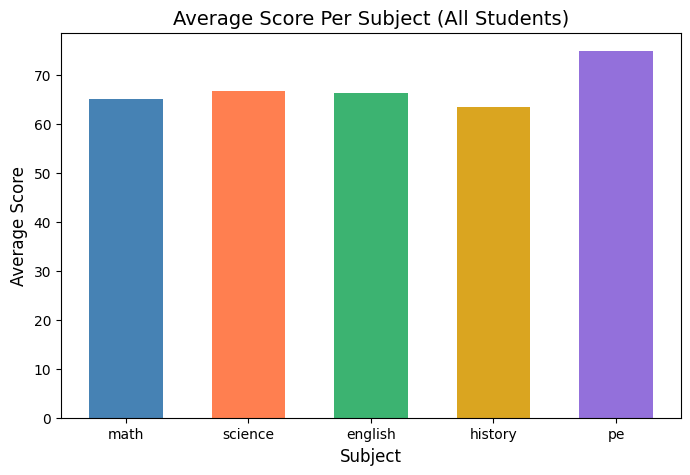

Saved as plot1_bar.png


In [17]:
## PLOT BARCHART

#calvulate average score per subject
subject_averages = df[subject_cols].mean() 
print('Subject averages:', subject_averages.round(2).to_dict())

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    subject_cols,              # x-axis: subject names
    subject_averages,       # y-axis: average scores
    color=['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'mediumpurple'],
    width=0.6
)
plt.title('Average Score Per Subject (All Students)', fontsize=14)
plt.xlabel('Subject', fontsize=12)
plt.ylabel('Average Score', fontsize=12)

plt.savefig('plot1_bar.png', dpi=150)  # save to file
plt.show()                     # display in notebook
print("Saved as plot1_bar.png")



Mean math score: 65.00


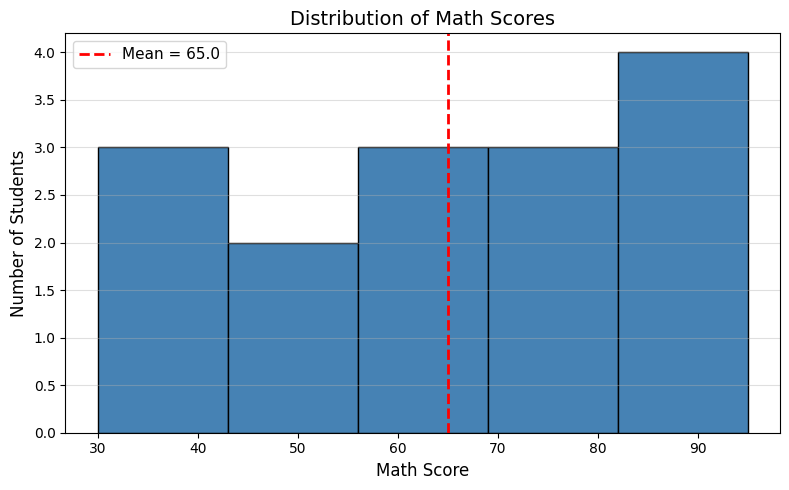

Saved as plot2_histogram.png


In [21]:
#Histogram of math scores

math_mean = df['math'].mean()
print(f'Mean math score: {math_mean:.2f}')

plt.figure(figsize=(8, 5))

plt.hist(
    df['math'],       # the data column
    bins=5,           
    color='steelblue',
    edgecolor='black',
)
#vertical line for mean
plt.axvline( 
    x=math_mean,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {math_mean:.1f}'
)
plt.legend(fontsize=11)

plt.title('Distribution of Math Scores', fontsize=14)
plt.xlabel('Math Score', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

plt.savefig('plot2_histogram.png', dpi=150)
plt.show()
print("Saved as plot2_histogram.png")



Passing students: 9
Failing students: 6


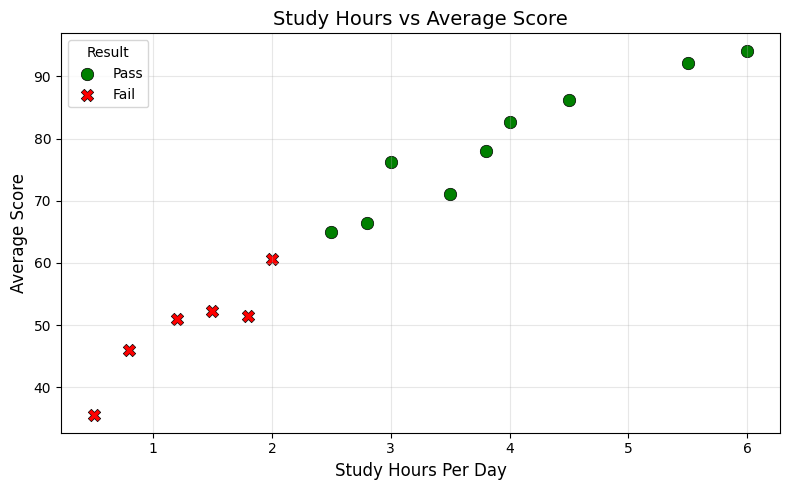

Saved as plot3_scatter.png


In [24]:
# Scatter plot of study hours vs average score

#seperating data into pass and fail groups
pass_df = df[df['passed'] == 1]   # all rows where passed == 1
fail_df = df[df['passed'] == 0]   # all rows where passed == 0

print(f'Passing students: {len(pass_df)}')
print(f'Failing students: {len(fail_df)}')

plt.figure(figsize=(8, 5))

# First scatter call: passing students (green dots)
plt.scatter(
    pass_df['study_hours_per_day'],  # x values
    pass_df['avg_score'],            # y values
    color='green',
    marker='o',                      # 'o' = circle marker
    s=80,                            # marker size (area in points squared)
    label='Pass',
    edgecolors='black',
    linewidths=0.5
)
# Second scatter call: failing students (red dots)
plt.scatter(
    fail_df['study_hours_per_day'],
    fail_df['avg_score'],
    color='red',
    marker='X',                      # 'X' = cross marker — visually distinct from 'o'
    s=80,
    label='Fail',
    edgecolors='black',
    linewidths=0.5
)

plt.title('Study Hours vs Average Score', fontsize=14)
plt.xlabel('Study Hours Per Day', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.legend(title='Result', fontsize=10)   # title= adds a small header to the legend box
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('plot3_scatter.png', dpi=150)
plt.show()
print("Saved as plot3_scatter.png")


Pass attendance values: [92, 85, 98, 78, 88, 80, 72, 95, 84]
Fail attendance values: [65, 58, 60, 50, 62, 70]


C:\Users\RENY\AppData\Local\Temp\ipykernel_10336\3059727677.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


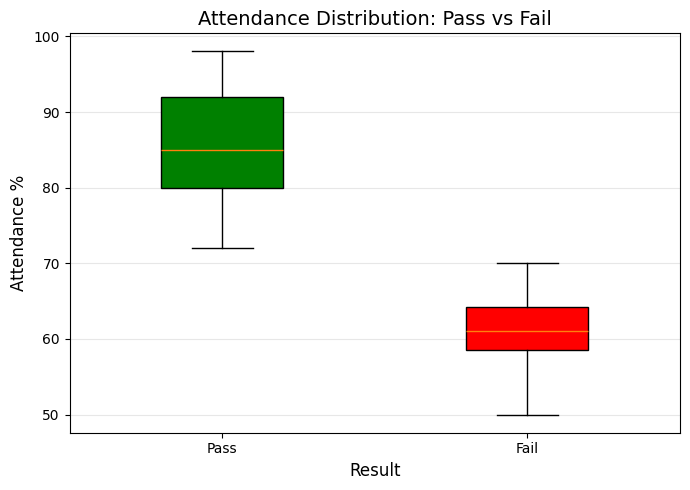

Saved as plot4_boxplot.png


In [ ]:
##BOX PLOT 

# Extract attendance values for each group as plain Python lists
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

print('Pass attendance values:', pass_attendance)
print('Fail attendance values:', fail_attendance)

plt.figure(figsize=(7, 5))


bp = plt.boxplot(
    [pass_attendance, fail_attendance],
    labels=['Pass', 'Fail'],
    patch_artist=True,   # fills boxes with colour 
    widths=0.4
)

# Colouring the boxes 
# index 0 = Pass, index 1 = Fail
bp['boxes'][0].set_facecolor('green')
bp['boxes'][1].set_facecolor('red')

plt.title('Attendance Distribution: Pass vs Fail', fontsize=14)
plt.xlabel('Result', fontsize=12)
plt.ylabel('Attendance %', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('plot4_boxplot.png', dpi=150)
plt.show()
print("Saved as plot4_boxplot.png")

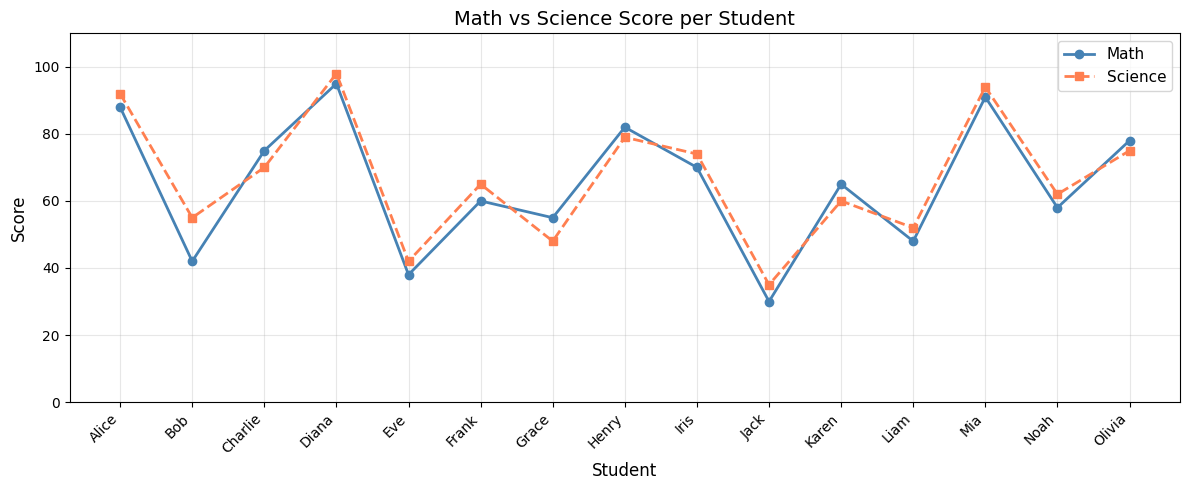

Saved as plot5_lineplot.png


In [29]:
## LINE PLOT
x_positions = list(range(len(df)))

plt.figure(figsize=(12, 5))

# Plot math scores — solid line with circle markers
plt.plot(
    x_positions,
    df['math'],
    marker='o',       # mark each data point with a circle
    linestyle='-',    # solid line
    color='steelblue',
    linewidth=2,
    markersize=6,
    label='Math'
)

# Plot science scores — dashed line with square markers
plt.plot(
    x_positions,
    df['science'],
    marker='s',       # square marker
    linestyle='--',   # dashed line
    color='coral',
    linewidth=2,
    markersize=6,
    label='Science'
)
# Replace 0,1,2... with student names on the x-axis
plt.xticks(ticks=x_positions, labels=df['name'].tolist(), rotation=45, ha='right')

plt.title('Math vs Science Score per Student', fontsize=14)
plt.xlabel('Student', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(fontsize=11)
plt.ylim(0, 110)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('plot5_lineplot.png', dpi=150)
plt.show()
print("Saved as plot5_lineplot.png")



## Task 3 — Data Visualization with Seaborn 

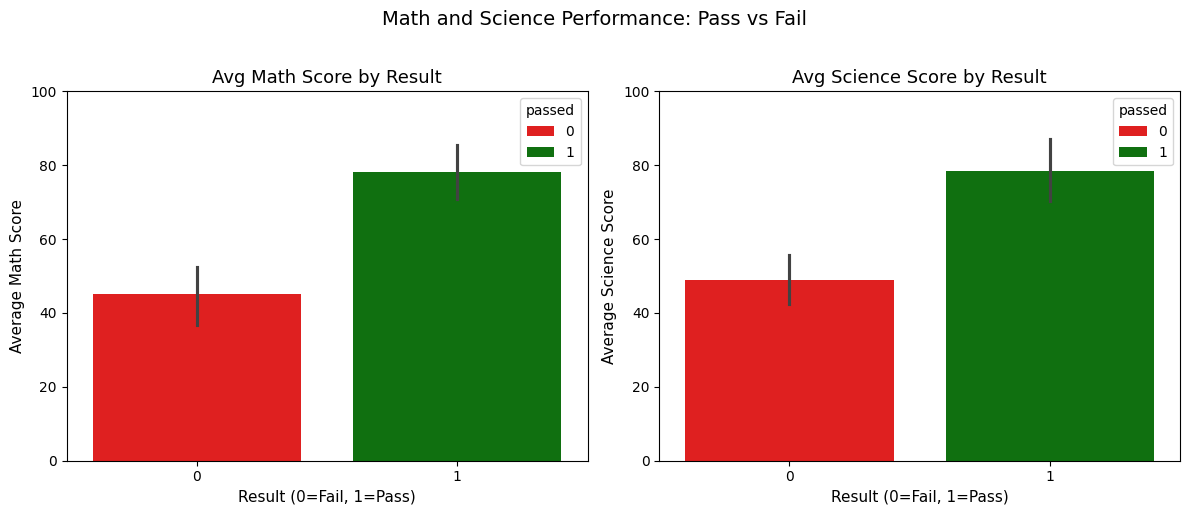

Saved as plot6_seaborn_bar.png


In [33]:
## Figure 1 :Math and Science average by Pass/Fail

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) # create 1 row, 2 columns of subplots

sns.barplot(
    data=df,
    x='passed',
    y='math',
    hue='passed',        # colour bars differently per group
    palette=['red', 'green'],
    ax=ax1
)
ax1.set_title('Avg Math Score by Result', fontsize=13)
ax1.set_xlabel('Result (0=Fail, 1=Pass)', fontsize=11)
ax1.set_ylabel('Average Math Score', fontsize=11)
ax1.set_ylim(0, 100)

# Second barplot for science(ax2)
sns.barplot(
    data=df,
    x='passed',
    y='science',
    hue='passed',
    palette=['red', 'green'],
    ax=ax2
)
ax2.set_title('Avg Science Score by Result', fontsize=13)
ax2.set_xlabel('Result (0=Fail, 1=Pass)', fontsize=11)
ax2.set_ylabel('Average Science Score', fontsize=11)
ax2.set_ylim(0, 100)

plt.suptitle('Math and Science Performance: Pass vs Fail', fontsize=14, y=1.02)
plt.tight_layout()

plt.savefig('plot6_seaborn_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as plot6_seaborn_bar.png")


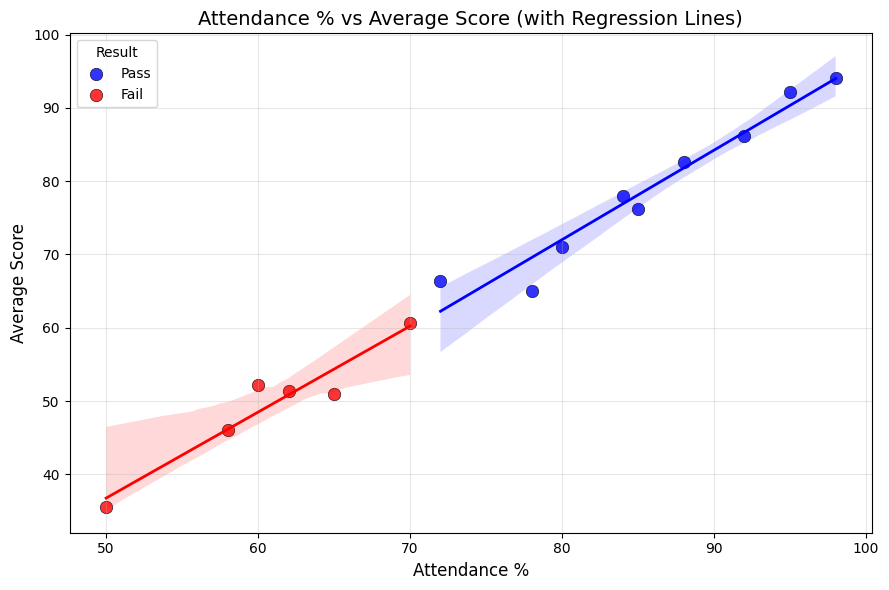

Saved as plot7_seaborn_regplot.png


In [39]:
## Figure 2: SCATTER PLOT OF ATTENDANCE PERCENTAGE VS AVERAGE SCORE, COLOURED BY PASS/FAIL

plt.figure(figsize=(9, 6))

# Pass group- blue
sns.regplot(
    data=df[df['passed'] == 1],   # filtering data before passing to seaborn
    x='attendance_pct',
    y='avg_score',
    color='blue',
    label='Pass',
    scatter_kws={'s': 80, 'edgecolors': 'black', 'linewidths': 0.5},
    line_kws={'linewidth': 2}
)

# Fail group - red
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    color='red',
    label='Fail',
    scatter_kws={'s': 80, 'edgecolors': 'black', 'linewidths': 0.5},
    line_kws={'linewidth': 2}
)

plt.title('Attendance % vs Average Score (with Regression Lines)', fontsize=14)
plt.xlabel('Attendance %', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.legend(title='Result', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('plot7_seaborn_regplot.png', dpi=150)
plt.show()
print("Saved as plot7_seaborn_regplot.png")

## Seaborn vs Matplotlib: Comparison

Seaborn required noticeably less code for the bar chart. 
sns.barplot() automatically computed group means and added confidence interval error bars which would have needed several extra lines in Matplotlib.
Fitting and drawing a regression line in Matplotlib would require importing numpy and computing coefficients manually then plotting the line separately. Seaborn does all that in one call.
Matplotlib gave more precise control over every visual detail.Seaborn's defaults look polished but customising small details sometimes requires dropping back down to Matplotlib commands.


In [53]:
print("Summary: Seaborn is faster for statistical charts (bar, reg, heatmap).")
print("Matplotlib is better when you need full pixel-level control.")


Summary: Seaborn is faster for statistical charts (bar, reg, heatmap).
Matplotlib is better when you need full pixel-level control.


## Task 4 — Machine Learning with scikit-learn 


In [52]:
# Separate features and target variable
# We exclude'name' (not a number),'passed' (target) , 'avg_score' because it's derived from the subject columns
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]   # DataFrame with only the feature columns
y = df['passed']       # Series with only the target column

print(X.head(3))
print()
print('Target (y) — first 5 values:')
print(y.head())

   math  science  english  history  pe  attendance_pct  study_hours_per_day
0    88       92       76       80  95              92                  4.5
1    42       55       48       50  60              65                  1.2
2    75       70       80       68  88              85                  3.0

Target (y) — first 5 values:
0    1
1    0
2    1
3    1
4    0
Name: passed, dtype: int64


In [ ]:
# Step 1b: Split into training set and test set 

# test_size=0.2 means 20% of rows go to test, 80% to training
# With 15 rows: 12 for training, 3 for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape[0]} students')
print(f'Test set    : {X_test.shape[0]} students')
print()


Training set: 12 students
Test set    : 3 students



In [42]:
##Step 1c: Scale the features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train and transform train
X_test_scaled = scaler.transform(X_test)        # transform test using same scaler 


In [44]:
#Step 2: Train the model

model = LogisticRegression(max_iter=1000, random_state=42) #create model object with specified parameters
model.fit(X_train_scaled, y_train) # train the model on the training data

train_preds = model.predict(X_train_scaled)
train_acc   = accuracy_score(y_train, train_preds)

print(f'Model trained successfully!')
print(f'Training accuracy: {train_acc * 100:.2f}%')



Model trained successfully!
Training accuracy: 100.00%


In [ ]:
## Step 3: Evaluate on test set
y_pred = model.predict(X_test_scaled)  #to get predictions for test set
test_acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {test_acc * 100:.2f}%')

print("Individual predictions")
print('-' * 20)

test_names = df.loc[X_test.index, 'name'].tolist()
actual_list = y_test.tolist()
pred_list   = y_pred.tolist()

for name, actual, predicted in zip(test_names, actual_list, pred_list):
    #To Convert 1/0 to readable labels
    actual_label    = 'Pass' if actual    == 1 else 'Fail'
    predicted_label = 'Pass' if predicted == 1 else 'Fail'

    #To Check if the prediction was correct
    correct = 'Correct' if actual == predicted else 'WRONG'
    icon    = 'v' if actual == predicted else 'X'

    print(f'  {name:<10}  Actual: {actual_label:<5}  Predicted: {predicted_label:<5}  [{icon}] {correct}')

Test accuracy: 100.00%
Individual predictions
--------------------
  Jack        Actual: Fail   Predicted: Fail   [v] Correct
  Liam        Actual: Fail   Predicted: Fail   [v] Correct
  Alice       Actual: Pass   Predicted: Pass   [v] Correct


In [46]:
##  Print coefficients sorted by importance
coefficients = model.coef_[0]

print('Feature coefficients (sorted by absolute value with largest being most influential):')
print('-' * 50)

# Pairing each feature name with its coefficient value
coef_pairs = list(zip(feature_cols, coefficients))

# Sorting by absolute values
coef_pairs_sorted = sorted(coef_pairs, key=lambda pair: abs(pair[1]), reverse=True)

for feature, coef in coef_pairs_sorted:
    direction = 'towards Pass' if coef > 0 else 'towards Fail'
    print(f'  {feature:<25} coef = {coef:>7.4f}   ({direction})')



Feature coefficients (sorted by absolute value with largest being most influential):
--------------------------------------------------
  english                   coef =  0.8125   (towards Pass)
  attendance_pct            coef =  0.5219   (towards Pass)
  study_hours_per_day       coef =  0.4844   (towards Pass)
  pe                        coef =  0.4750   (towards Pass)
  math                      coef =  0.4379   (towards Pass)
  science                   coef =  0.3230   (towards Pass)
  history                   coef =  0.2629   (towards Pass)


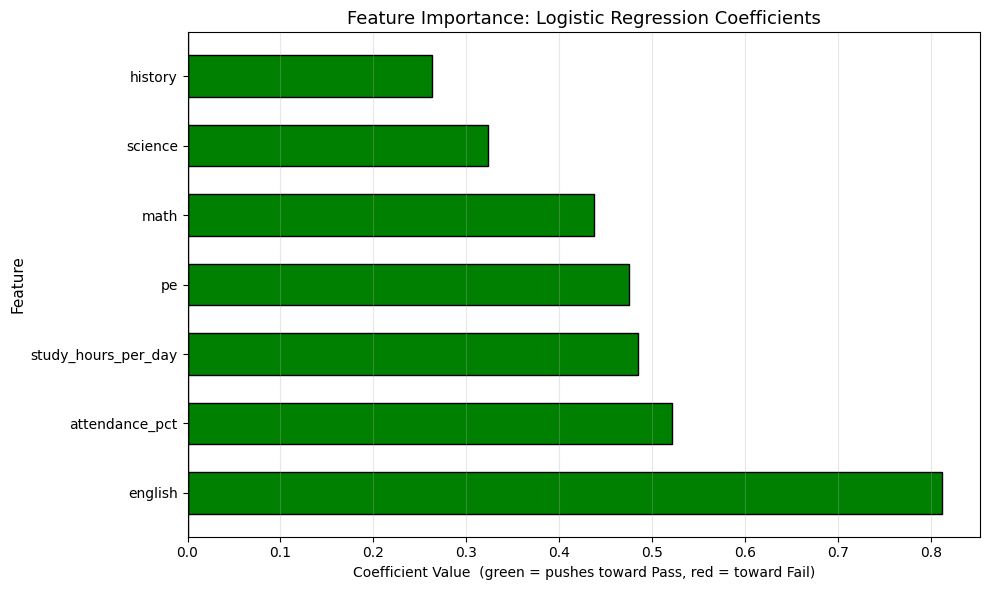

Saved as plot8_feature_importance.png


In [47]:
# Horizontal bar chart of coefficients

# Re-sort for the chart with highest positive at top and most negative at bottom
sorted_features = [p[0] for p in coef_pairs_sorted]
sorted_coefs    = [p[1] for p in coef_pairs_sorted]

#Assingning color
bar_colors = ['green' if c > 0 else 'red' for c in sorted_coefs]

plt.figure(figsize=(10, 6))

# y = the labels (feature names), width = the bar lengths (coefficient values)
plt.barh(
    sorted_features,  # y-axis labels
    sorted_coefs,     # bar widths
    color=bar_colors,
    edgecolor='black',
    height=0.6
)
plt.axvline(x=0, color='black', linewidth=1) #vertical line

plt.title('Feature Importance: Logistic Regression Coefficients', fontsize=13)
plt.xlabel('Coefficient Value  (green = pushes toward Pass, red = toward Fail)', fontsize=10)
plt.ylabel('Feature', fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot8_feature_importance.png', dpi=150)
plt.show()
print("Saved as plot8_feature_importance.png")

In [51]:
import warnings
warnings.filterwarnings("ignore")
## Step 5 — Predict for a New Student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)  # scale using same scaler as training data
new_pred = model.predict(new_student_scaled)[0]  # predict returns an array, we want the first element  
print(f'Predicted outcome for the new student: {new_pred}')


# Predict the probability of each class
probabilities = model.predict_proba(new_student_scaled)[0]
prob_fail = probabilities[0]   #probability of class 0 (Fail)
prob_pass = probabilities[1]   #probability of class 1 (Pass)

result_label = 'PASS' if new_pred == 1 else 'FAIL'
print(f'Predicted result: {result_label} (Pass probability: {prob_pass:.2%}, Fail probability: {prob_fail:.2%})')

if prob_pass >= 0.7:
    print('  The model is fairly confident this student will pass.')
elif prob_pass >= 0.5:
    print('  The model leans toward Pass but is not very confident.')
else:
    print('  The model predicts Fail.')



Predicted outcome for the new student: 1
Predicted result: PASS (Pass probability: 90.80%, Fail probability: 9.20%)
  The model is fairly confident this student will pass.
